# Linear Regression: Baseline Modeling and Diagnostics

## Project

Linear and Regularized Regression for Used-Car Price Prediction

## Notebook Purpose

This notebook develops and evaluates the first regression model for used-car
Price prediction.

Linear Regression will serve as the main interpretable baseline for later
comparison with Ridge, Lasso, and Elastic Net regression.

The notebook will:

- establish a simple dummy baseline;
- train Linear Regression using original Price;
- train Linear Regression using log-transformed Price;
- evaluate predictions using MAE, RMSE, and R²;
- compare actual and predicted vehicle Prices;
- examine residual patterns and influential observations;
- inspect coefficient interpretation and multicollinearity;
- document the strengths and limitations of the linear model.

All learned preprocessing operations will remain inside the modeling pipeline
to prevent data leakage during cross-validation.

## 1. Modeling Principles

The same dataset, feature-engineering rules, train-test split, and evaluation
metrics will be used across all linear and regularized regression models.

The test set will not be used for model selection or parameter tuning. It will
be evaluated only after the modeling decisions have been learned from the
training data.

Performance will first be compared against a dummy baseline. A regression
model is useful only if it performs better than a simple prediction strategy.

## 2. Import Required Libraries


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.base import clone
from scipy import stats
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from statsmodels.tools.tools import add_constant

## 3. Load Data and Recreate the Train-Test Split

The raw dataset is loaded independently to keep this notebook reproducible.

The same test size and random state used in the preprocessing notebook recreate
the identical training and test observations for fair model comparison.

In [2]:
df = pd.read_csv(
    "../data/raw/car_price_data.csv"
)

X = df.drop(columns="Price")
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dataset shape:", df.shape)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Dataset shape: (2059, 20)
Training shape: (1647, 19)
Test shape: (412, 19)


## 4. Apply Deterministic Feature Engineering

The same fixed feature-engineering rules validated in the preprocessing
notebook are applied to the training and test features.

These rules do not learn statistics from the data, so they can be applied
before the learned preprocessing pipeline.

In [3]:
def first_number(series):
    return pd.to_numeric(
        series.str.extract(
            r"(\d+(?:\.\d+)?)",
            expand=False
        ),
        errors="coerce"
    )


def rpm_number(series):
    return pd.to_numeric(
        series.str.extract(
            r"@\s*(\d+(?:\.\d+)?)",
            expand=False
        ),
        errors="coerce"
    )


def engineer_features(data):
    data = data.copy()

    data["Vehicle Age"] = 2022 - data["Year"]
    data["Engine_CC"] = first_number(data["Engine"])
    data["Power_BHP"] = first_number(data["Max Power"])
    data["Power_RPM"] = rpm_number(data["Max Power"])
    data["Torque_NM"] = first_number(data["Max Torque"])
    data["Torque_RPM_Clean"] = rpm_number(
        data["Max Torque"]
    )

    data.loc[
        data["Torque_RPM_Clean"] < 500,
        "Torque_RPM_Clean"
    ] = np.nan

    data["Fuel Type"] = data["Fuel Type"].replace({
        "CNG + CNG": "CNG"
    })

    data["Owner"] = data["Owner"].replace({
        "Fourth": "Fourth or More",
        "4 or More": "Fourth or More"
    })

    return data.drop(
        columns=[
            "Year",
            "Engine",
            "Max Power",
            "Max Torque"
        ]
    )

In [4]:
X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)

print("Training engineered shape:", X_train_eng.shape)
print("Test engineered shape:", X_test_eng.shape)
print("Year removed:", "Year" not in X_train_eng.columns)

Training engineered shape: (1647, 21)
Test engineered shape: (412, 21)
Year removed: True


## 5. Define the Preprocessing Pipeline

Numerical features receive median imputation, missing-value indicators, and
standardization.

Categorical features receive explicit missing-value treatment, rare-category
grouping, and reference-based one-hot encoding.

In [5]:
numerical_features = [
    "Kilometer", "Length", "Width", "Height",
    "Seating Capacity", "Fuel Tank Capacity",
    "Vehicle Age", "Engine_CC", "Power_BHP",
    "Power_RPM", "Torque_NM", "Torque_RPM_Clean"
]

categorical_features = [
    "Make", "Model", "Fuel Type", "Transmission",
    "Location", "Color", "Owner",
    "Seller Type", "Drivetrain"
]

numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5,
            drop="first"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

### 6.1 Define and Fit the Dummy Model

The mean-based Dummy Regressor is fitted using the training data. It does not
learn relationships between input features and Price.

In [7]:
dummy_model = DummyRegressor(
    strategy="mean"
)

dummy_model.fit(
    X_train_eng,
    y_train
)

,strategy,'mean'
,constant,None
,quantile,None


### 6.2 Generate Dummy Predictions

The fitted dummy model predicts the same training-set mean Price for every test
vehicle.

In [8]:
dummy_predictions = dummy_model.predict(
    X_test_eng
)

print(
    "Number of predictions:",
    len(dummy_predictions)
)

print(
    "Predicted Price for every car:",
    round(dummy_predictions[0], 2)
)

Number of predictions: 412
Predicted Price for every car: 1696655.08


### 6.3 Evaluate the Dummy Baseline

The predictions are evaluated using MAE, RMSE, and R². These results establish
the minimum performance reference for the trained regression models.

In [9]:
dummy_mae = mean_absolute_error(
    y_test,
    dummy_predictions
)

dummy_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dummy_predictions
    )
)

dummy_r2 = r2_score(
    y_test,
    dummy_predictions
)

print("Dummy MAE:", round(dummy_mae, 2))
print("Dummy RMSE:", round(dummy_rmse, 2))
print("Dummy R²:", round(dummy_r2, 4))

Dummy MAE: 1454531.38
Dummy RMSE: 2643347.32
Dummy R²: -0.0001


### Dummy Baseline Interpretation

The dummy model predicted the training-set mean Price of approximately
1.70 million for all 412 test vehicles.

Its MAE is approximately 1.45 million, while RMSE is approximately 2.64
million. The higher RMSE indicates that a small number of large prediction
errors have a strong effect on the squared-error metric.

The R² score is approximately zero because the dummy model does not explain
vehicle-to-vehicle Price variation.

Linear Regression should produce lower MAE and RMSE and a clearly positive R²
to demonstrate useful predictive learning.

## 7. Linear Regression Using Original Price

### 7.1 Define and Fit the Model

The preprocessing pipeline and Linear Regression are combined into one
leakage-safe modeling pipeline.

The model is fitted using the original Price target, so its prediction errors
remain directly interpretable in currency units.

In [12]:
linear_raw_model = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_raw_model.fit(
    X_train_eng,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 7.2 Generate Test Predictions

The fitted Linear Regression pipeline applies the training-fitted
preprocessing rules to the unseen test features and generates one Price
prediction for each test vehicle.

In [13]:
linear_raw_predictions = linear_raw_model.predict(
    X_test_eng
)

print(
    "Number of predictions:",
    len(linear_raw_predictions)
)

print(
    "First 5 predicted Prices:"
)

linear_raw_predictions[:5]

Number of predictions: 412
First 5 predicted Prices:


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([4022815.66834607, 1053136.99948868,  -92910.68816144,
       1309962.37059228,  971444.97235133])

### Prediction Observation

The model generated 412 test predictions.

Some test categories were not observed during training. Because the encoder
uses `handle_unknown="ignore"`, these categories were safely represented by
zero values instead of causing a prediction error. This reflects a realistic
unseen-category scenario.

At least one prediction is negative. Ordinary Linear Regression does not
constrain predictions to the valid positive Price range. Negative predictions
will be quantified and compared with the log-target model rather than being
silently corrected.

### 7.3 Evaluate the Original-Price Model

The test predictions are evaluated using the same metrics as the dummy
baseline. The number of negative predictions is also reported as a logical
validity check.

In [14]:
linear_raw_mae = mean_absolute_error(
    y_test,
    linear_raw_predictions
)

linear_raw_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_raw_predictions
    )
)

linear_raw_r2 = r2_score(
    y_test,
    linear_raw_predictions
)

negative_predictions = (
    linear_raw_predictions < 0
).sum()

print("Linear MAE:", round(linear_raw_mae, 2))
print("Linear RMSE:", round(linear_raw_rmse, 2))
print("Linear R²:", round(linear_raw_r2, 4))
print("Negative predictions:", negative_predictions)

Linear MAE: 658647.69
Linear RMSE: 1414702.1
Linear R²: 0.7135
Negative predictions: 71


### Original-Price Model Interpretation

Linear Regression substantially outperformed the dummy baseline.

The model reduced MAE from approximately 1.45 million to 0.66 million and
RMSE from approximately 2.64 million to 1.41 million. Its R² of 0.7135
indicates that the model explains approximately 71.35% of the test-set Price
variation.

However, 71 of the 412 predictions are negative. These predictions are not
logically valid for vehicle Price and show that unconstrained Linear Regression
can extrapolate below zero.

The raw-target model is predictive, but its logical validity and residual
behaviour require further investigation.

## 8. Linear Regression Using Log-Transformed Price

### 8.1 Prepare the Log Training Target

Only the training target is transformed for model fitting. The original test
Price remains unchanged for final evaluation in currency units.

In [15]:
y_train_log = np.log1p(
    y_train
)

print(
    "Original training skewness:",
    round(y_train.skew(), 2)
)

print(
    "Log training skewness:",
    round(y_train_log.skew(), 2)
)

Original training skewness: 4.45
Log training skewness: 0.46


### 8.2 Define and Fit the Log-Price Model

A fresh preprocessing and Linear Regression pipeline is fitted using
log-transformed training Price.

A separate pipeline prevents fitted preprocessing state from being shared
between the original-target and log-target experiments.

In [16]:
linear_log_model = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_log_model.fit(
    X_train_eng,
    y_train_log
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 8.3 Generate and Invert Predictions

The model first predicts log-transformed Price. The predictions are then
converted back to original currency units using the inverse transformation.

Prediction generation and inverse transformation are kept separate for
clarity.

In [17]:
linear_log_predictions = linear_log_model.predict(
    X_test_eng
)

print(
    "Number of log predictions:",
    len(linear_log_predictions)
)

print(
    "First 5 log predictions:"
)

linear_log_predictions[:5]

Number of log predictions: 412
First 5 log predictions:


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([15.29371223, 13.4963476 , 13.27321466, 13.96953286, 13.32470231])

In [18]:
linear_log_price_predictions = np.expm1(
    linear_log_predictions
)

print(
    "First 5 predictions in original Price:"
)

linear_log_price_predictions[:5]

First 5 predictions in original Price:


array([4385051.80145327,  726756.11034912,  581410.85610126,
       1166515.90529934,  612130.43951808])

### Log-Model Prediction Observation

The model generated 412 predictions on the log scale. These predictions were
converted back to original Price units using `np.expm1()`.

Unknown test categories were handled safely using the training-fitted encoder.
The first inverse-transformed predictions are positive and interpretable in
currency units.

### 8.4 Evaluate the Log-Price Model

The inverse-transformed predictions are evaluated against the original test
Prices. This keeps MAE and RMSE directly interpretable in currency units and
allows fair comparison with the original-target model and dummy baseline.

In [19]:
linear_log_mae = mean_absolute_error(
    y_test,
    linear_log_price_predictions
)

linear_log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_log_price_predictions
    )
)

linear_log_r2 = r2_score(
    y_test,
    linear_log_price_predictions
)

log_negative_predictions = (
    linear_log_price_predictions < 0
).sum()

print("Log Linear MAE:", round(linear_log_mae, 2))
print("Log Linear RMSE:", round(linear_log_rmse, 2))
print("Log Linear R²:", round(linear_log_r2, 4))
print(
    "Negative predictions:",
    log_negative_predictions
)

Log Linear MAE: 302345.26
Log Linear RMSE: 996774.47
Log Linear R²: 0.8578
Negative predictions: 0


### Log-Price Model Interpretation

The log-target Linear Regression model substantially outperformed both the
dummy baseline and the original-target Linear Regression model.

After inverse transformation, its MAE is approximately 302 thousand and its
RMSE is approximately 997 thousand. The R² score of 0.8578 indicates that the
model explains approximately 85.78% of the Price variation in the test set.

The model produced no negative Price predictions. Log-target modeling therefore
improved predictive accuracy and logical validity for this dataset.

However, the RMSE remains much larger than MAE, indicating that some expensive
or difficult vehicles still produce large absolute errors. Residual and
extreme-case analysis is required before considering the model reliable.

## 9. Compare Baseline and Linear Models

The dummy baseline, original-target Linear Regression, and log-target Linear
Regression are compared using the same unseen test observations and original
Price units.

In [20]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Linear Regression",
        "Log-Target Linear Regression"
    ],
    "MAE": [
        dummy_mae,
        linear_raw_mae,
        linear_log_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_raw_rmse,
        linear_log_rmse
    ],
    "R2": [
        dummy_r2,
        linear_raw_r2,
        linear_log_r2
    ],
    "Negative Predictions": [
        0,
        negative_predictions,
        log_negative_predictions
    ]
})

model_comparison.round(4)

,Model,MAE,RMSE,R2,Negative Predictions
0,Dummy Baseline,1.454531e+06,2.643347e+06,-0.0001,0
1,Linear Regression,6.586477e+05,1.414702e+06,0.7135,71
2,Log-Target Linear Regression,3.023453e+05,9.967745e+05,0.8578,0


### Model-Comparison Interpretation

Both Linear Regression models substantially outperform the dummy baseline.

The original-target model explains 71.35% of the test Price variation but
produces 71 invalid negative predictions.

The log-target model achieves the lowest MAE and RMSE, the highest R², and no
negative predictions. It is therefore the strongest Linear Regression approach
among the current experiments.

This conclusion is provisional. Prediction plots, residual diagnostics,
cross-validation, and extreme-case analysis are still required.

## 10. Actual Versus Predicted Prices

An Actual-versus-Predicted plot visually evaluates prediction agreement.

Perfect predictions would lie on the diagonal reference line. Greater distance
from this line represents larger prediction error.

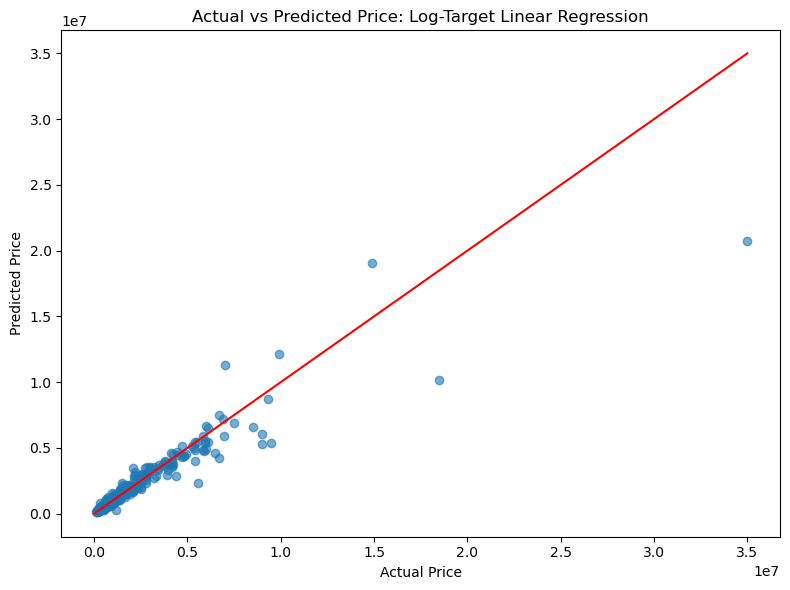

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_log_price_predictions,
    alpha=0.6
)

price_limit = max(
    y_test.max(),
    linear_log_price_predictions.max()
)

plt.plot(
    [0, price_limit],
    [0, price_limit],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(
    "Actual vs Predicted Price: Log-Target Linear Regression"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/linear_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Actual-versus-Predicted Interpretation

Most low- and medium-price vehicles lie relatively close to the diagonal
reference line, indicating reasonable prediction accuracy in the main market
range.

Prediction errors become larger for expensive vehicles. The 35-million vehicle
is substantially underpredicted, and several other luxury vehicles also lie far
from the perfect-prediction line.

The model therefore performs well for the majority of observations but has
difficulty representing some extreme luxury-market values. This explains why
RMSE remains much larger than MAE.

## 11. Residual Analysis

A residual is the difference between an observed Price and its predicted Price.

Positive residuals represent underprediction, while negative residuals
represent overprediction.

In [22]:
log_model_residuals = (
    y_test.to_numpy()
    - linear_log_price_predictions
)

print(
    "Number of residuals:",
    len(log_model_residuals)
)

print(
    "Mean residual:",
    round(log_model_residuals.mean(), 2)
)

print(
    "First 5 residuals:"
)

log_model_residuals[:5]

Number of residuals: 412
Mean residual: 74229.08
First 5 residuals:


array([ 414948.19854673,   98243.88965088,  113589.14389874,
       -216515.90529934,  207868.56048192])

### Residual Calculation Interpretation

The model has a positive mean residual of approximately 74 thousand, indicating
a slight overall tendency to underpredict test Prices.

Individual residuals contain both positive and negative values. Positive and
negative errors can cancel when calculating the mean residual, so the mean
residual should not replace MAE or RMSE.

### 11.1 Residuals Versus Predicted Price

A well-behaved regression model should produce residuals that are randomly
scattered around zero without a clear curve, trend, or expanding spread.

Patterns in this graph can reveal nonlinearity, unequal error variance, and
systematic underprediction or overprediction.

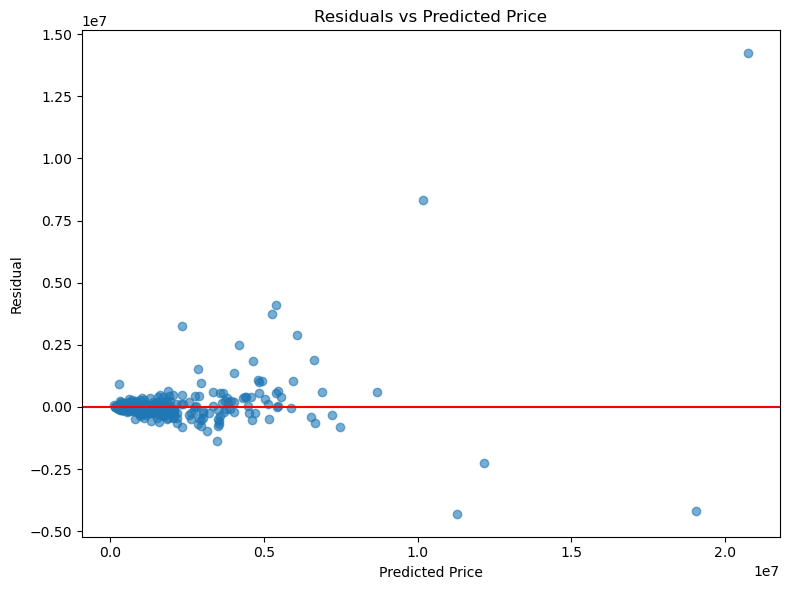

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    linear_log_price_predictions,
    log_model_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(
    "Residuals vs Predicted Price"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/linear_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Original-Scale Residual Interpretation

Residuals are relatively concentrated around zero for low- and medium-price
vehicles, while their spread increases substantially for expensive vehicles.

This indicates unequal absolute error variance on the original Price scale.
Several luxury vehicles produce very large positive or negative residuals,
confirming that they dominate RMSE.

However, this model was fitted on Log Price rather than original Price.
Therefore, formal Linear Regression residual diagnostics should also be
performed on the log scale. The original-scale residual plot remains important
for understanding prediction errors in real currency units.

### 11.2 Calculate Log-Scale Residuals

Because the model was trained on Log Price, its statistical residual diagnostics
must be examined on the same scale.

Log-scale residuals represent differences between actual and predicted
log-transformed Prices.

In [24]:
y_test_log = np.log1p(y_test)

log_scale_residuals = (
    y_test_log.to_numpy()
    - linear_log_predictions
)

print(
    "Mean log residual:",
    round(log_scale_residuals.mean(), 4)
)

print(
    "Standard deviation:",
    round(log_scale_residuals.std(), 4)
)

print(
    "First 5 log residuals:"
)

log_scale_residuals[:5]

Mean log residual: -0.0003
Standard deviation: 0.2094
First 5 log residuals:


array([ 0.09041446,  0.12679228,  0.1784539 , -0.20531455,  0.29235731])

### Log-Residual Summary

The mean log-scale residual is approximately zero, indicating that positive and
negative log errors are balanced overall.

The residual standard deviation is approximately 0.21. However, a near-zero
mean does not prove that the linear-model assumptions are satisfied. Residual
shape and variance must be examined visually.

### 11.3 Log-Scale Residuals Versus Predicted Log Price

This plot evaluates residual behaviour on the same scale used to fit the model.

A desirable pattern consists of residuals randomly distributed around zero
with approximately constant spread across predicted values.

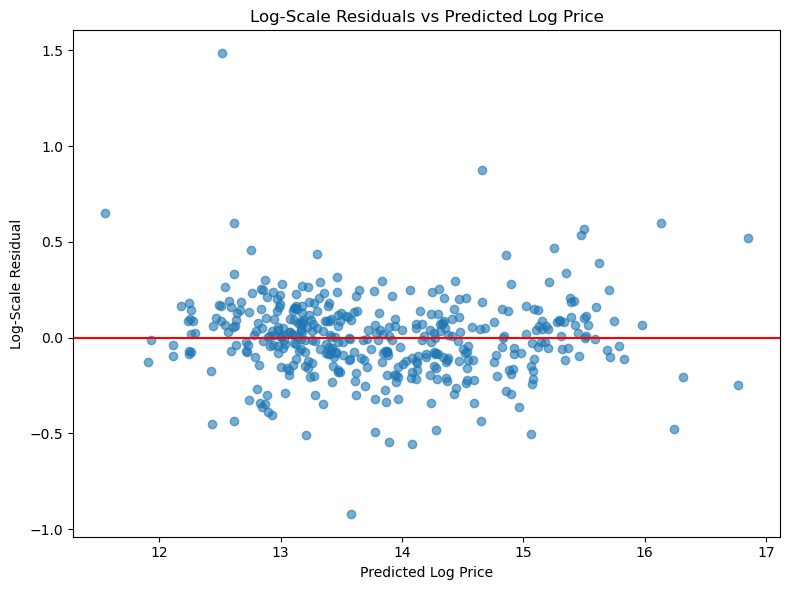

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    linear_log_predictions,
    log_scale_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Log Price")
plt.ylabel("Log-Scale Residual")
plt.title(
    "Log-Scale Residuals vs Predicted Log Price"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/linear_log_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Scale Residual-Plot Interpretation

The log-scale residuals are more evenly distributed around zero than the
original-scale residuals. The strong expansion in absolute error observed on
the original Price scale is substantially reduced.

Most observations have relatively small residuals, although several extreme
positive and negative errors remain.

A mild systematic pattern is visible across the predicted range, suggesting
that some nonlinear relationships, vehicle segments, or feature interactions
may not be completely represented by the linear model.

The log transformation improved residual behaviour, but it did not make the
model assumptions perfect.

### 11.4 Distribution of Log-Scale Residuals

The residual distribution is inspected for symmetry, central location, and
extreme tails.

A roughly symmetric distribution centered near zero supports the normal-error
assumption, although a histogram alone cannot confirm normality.

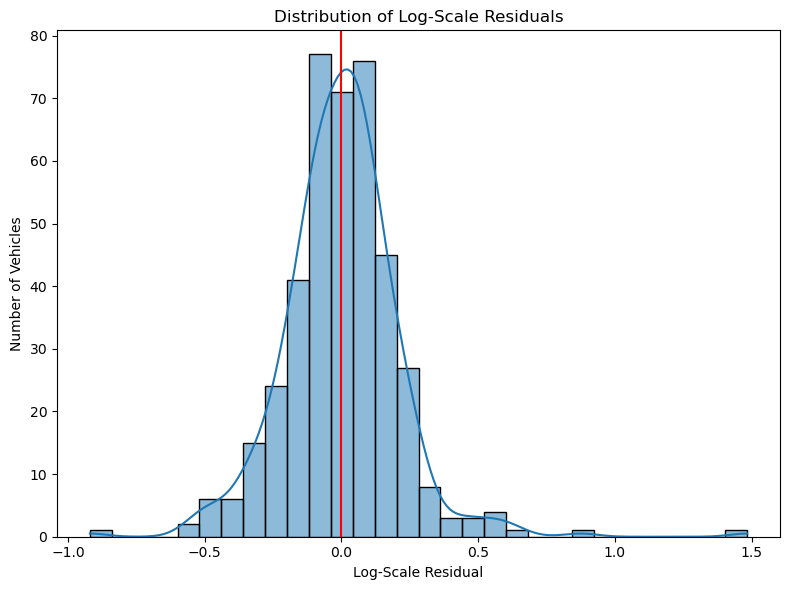

In [26]:
plt.figure(figsize=(8, 6))

sns.histplot(
    log_scale_residuals,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    color="red"
)

plt.xlabel("Log-Scale Residual")
plt.ylabel("Number of Vehicles")
plt.title(
    "Distribution of Log-Scale Residuals"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/linear_log_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Residual-Distribution Interpretation

The log-scale residual distribution is centered close to zero and the majority
of errors form an approximately bell-shaped central pattern.

However, the distribution is not perfectly symmetric. The longer positive tail
and several isolated extreme residuals indicate that a small number of vehicles
are substantially underpredicted.

The central residual behaviour is reasonable, but tail deviations suggest that
the normal-error assumption may not hold perfectly.

### 11.5 Q-Q Plot of Log-Scale Residuals

A Q-Q plot compares the observed residual quantiles with the quantiles expected
under a normal distribution.

Points close to the diagonal line support approximate normality. Systematic
departures, particularly at the ends, indicate skewness, heavy tails, or
extreme residuals.

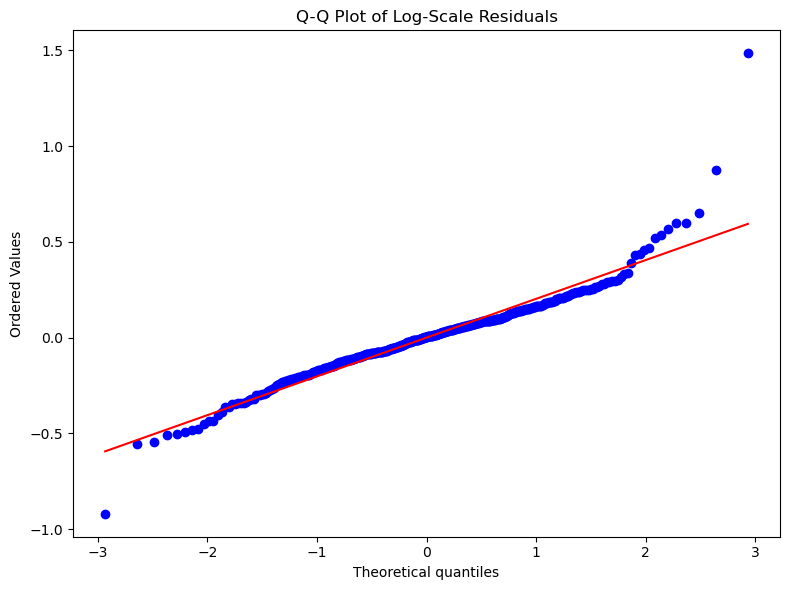

In [28]:
plt.figure(figsize=(8, 6))

stats.probplot(
    log_scale_residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Log-Scale Residuals"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/linear_log_residual_qqplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Q-Q Plot Interpretation

Most central residual quantiles lie reasonably close to the theoretical normal
line, indicating approximate normality for the majority of observations.

Both tails deviate from the reference line, with stronger deviation in the
positive tail. A small number of substantially underpredicted vehicles produce
heavy-tail behaviour and violate exact residual normality.

The model remains predictively useful, but normal-theory coefficient inference
and confidence intervals should be interpreted cautiously.

## 12. Investigate the Largest Prediction Errors

The largest absolute residuals are linked back to their original vehicle
records.

This helps determine whether poor predictions are caused by data-quality
problems, rare luxury vehicles, unseen categories, or limitations of the linear
model.

In [29]:
error_analysis = X_test[
    [
        "Make",
        "Model",
        "Year",
        "Kilometer"
    ]
].copy()

error_analysis["Actual Price"] = y_test
error_analysis["Predicted Price"] = (
    linear_log_price_predictions
)

error_analysis["Residual"] = (
    log_model_residuals
)

error_analysis["Absolute Error"] = abs(
    log_model_residuals
)

largest_errors = error_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

largest_errors.round(2)

,Make,Model,Year,Kilometer,Actual Price,Predicted Price,Residual,Absolute Error
483,Ferrari,488 GTB,2018,9500,35000000,20768964.84,14231035.16,14231035.16
1912,Mercedes-Benz,S-Class S 350D [2018-2020],2021,5000,18500000,10178057.56,8321942.44,8321942.44
1444,Mercedes-Benz,C-Coupe 43 AMG 4MATIC,2020,19000,7000000,11297888.97,-4297888.97,4297888.97
1803,Porsche,Cayenne Base,2021,7534,14900000,19080337.70,-4180337.70,4180337.70
785,Porsche,718 Boxster,2018,20000,9500000,5395564.96,4104435.04,4104435.04
464,Porsche,718 Cayman [2017-2020],2017,7000,9000000,5264566.02,3735433.98,3735433.98
1771,Porsche,Panamera 3.0 Diesel,2015,33000,5590000,2330986.87,3259013.13,3259013.13
233,Maserati,Levante Diesel,2017,40000,9000000,6086973.86,2913026.14,2913026.14
857,Audi,Q7 45 TDI Technology Pack,2018,39850,6700000,4197436.22,2502563.78,2502563.78
1164,Audi,Q8 Celebration,2021,28000,9900000,12170803.25,-2270803.25,2270803.25


### Largest-Error Interpretation

The largest absolute errors are concentrated among premium and luxury vehicles,
including Ferrari, Mercedes-Benz, Porsche, Maserati, and Audi models.

The model substantially underpredicts some rare high-value vehicles and
overpredicts others. This suggests that broad technical and categorical
features identify the luxury segment but do not fully capture variant-specific
market value.

These extreme cases explain the heavy residual tails and the large difference
between MAE and RMSE. Training-set frequencies must be examined before
concluding whether the errors are associated with unseen or rare vehicle
models.

### 12.1 Check Training Representation of Difficult Vehicles

The training frequencies of the corresponding Makes and exact Models are
examined.

A zero model count means the exact test Model was unseen during training. A low
count indicates that the model had limited evidence for learning its Price
pattern.

In [30]:
make_counts = X_train["Make"].value_counts()
model_counts = X_train["Model"].value_counts()

largest_errors["Training Make Count"] = (
    largest_errors["Make"].map(make_counts).fillna(0)
)

largest_errors["Training Model Count"] = (
    largest_errors["Model"].map(model_counts).fillna(0)
)

largest_errors[
    [
        "Make",
        "Model",
        "Actual Price",
        "Absolute Error",
        "Training Make Count",
        "Training Model Count"
    ]
].round(2)

,Make,Model,Actual Price,Absolute Error,Training Make Count,Training Model Count
483,Ferrari,488 GTB,35000000,14231035.16,0.0,0.0
1912,Mercedes-Benz,S-Class S 350D [2018-2020],18500000,8321942.44,141.0,1.0
1444,Mercedes-Benz,C-Coupe 43 AMG 4MATIC,7000000,4297888.97,141.0,0.0
1803,Porsche,Cayenne Base,14900000,4180337.70,9.0,0.0
785,Porsche,718 Boxster,9500000,4104435.04,9.0,1.0
464,Porsche,718 Cayman [2017-2020],9000000,3735433.98,9.0,0.0
1771,Porsche,Panamera 3.0 Diesel,5590000,3259013.13,9.0,1.0
233,Maserati,Levante Diesel,9000000,2913026.14,0.0,0.0
857,Audi,Q7 45 TDI Technology Pack,6700000,2502563.78,109.0,3.0
1164,Audi,Q8 Celebration,9900000,2270803.25,109.0,0.0


### Training-Frequency Interpretation

The largest errors are strongly associated with limited training
representation.

Ferrari and Maserati were completely absent from the training set. Several
exact luxury Models were also unseen, while others appeared only one to three
times.

Models occurring fewer than five times were grouped into an infrequent
category. This controls high-cardinality overfitting but prevents the model from
learning reliable variant-specific effects from extremely small samples.

The results represent an unseen-category generalization problem rather than
only a failure of coefficient estimation. Performance on common-market
vehicles and rare luxury vehicles should therefore be interpreted separately.

## 13. Cross-Validation Setup

Five-fold cross-validation evaluates the model across multiple training and
validation partitions.

Target transformation and preprocessing are fitted independently within each
fold. This prevents validation-fold information from entering the training
process.

In [32]:
cv_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearRegression())
])

cv_log_model = TransformedTargetRegressor(
    regressor=cv_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 13.2 Evaluate Across Five Folds

The model is independently fitted and evaluated five times. MAE, RMSE, and R²
are calculated on the original Price scale for every validation fold.

In [33]:
cv_results = cross_validate(
    cv_log_model,
    X_train_eng,
    y_train,
    cv=cv_strategy,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

cv_scores = pd.DataFrame({
    "MAE": -cv_results["test_MAE"],
    "RMSE": -cv_results["test_RMSE"],
    "R2": cv_results["test_R2"]
})

cv_scores.round(4)

C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders

,MAE,RMSE,R2
0,399665.4249,1.252210e+06,0.6642
1,361702.8133,1.198127e+06,0.7682
2,359962.7755,8.686092e+05,0.8593
3,345538.4359,1.083657e+06,0.8240
4,414952.6518,9.614566e+05,0.8127


### Fold-Level Cross-Validation Observation

The model performs better than the dummy baseline across all five validation
folds, but its performance varies between folds.

R² ranges from approximately 0.66 to 0.86. This variation indicates that model
performance is sensitive to which rare and expensive vehicles are placed in
each validation fold.

Unknown-category warnings occur because some Makes, Models, Locations, or other
categories appear only in a validation fold. They are handled safely by the
encoder and represent a realistic generalization challenge.

### 13.3 Summarize Cross-Validation Performance

Mean scores estimate average model performance, while standard deviations show
how much performance changes across data partitions.

In [34]:
cv_summary = pd.DataFrame({
    "Mean": cv_scores.mean(),
    "Standard Deviation": cv_scores.std()
})

cv_summary.round(4)

,Mean,Standard Deviation
MAE,3.763644e+05,29437.2486
RMSE,1.072812e+06,159768.4056
R2,7.857000e-01,0.0753


### Cross-Validation Summary

The model achieves a mean cross-validation MAE of approximately 376 thousand,
RMSE of approximately 1.07 million, and R² of 0.7857.

The R² standard deviation of 0.0753 indicates moderate variation across folds.
Performance depends partly on how rare and luxury vehicles are distributed
between training and validation subsets.

The final test R² of 0.8578 is stronger than the cross-validation mean but
remains within the observed fold range. Cross-validation therefore suggests
that approximately 0.79 R² is a more cautious estimate of general performance.

## 14. Inspect Linear Regression Coefficients

Linear Regression coefficients describe the direction and magnitude of each
processed feature's association with Log Price while other features are held
constant.

Numerical coefficients correspond to standardized features. Categorical
coefficients are interpreted relative to their dropped reference categories.

In [35]:
fitted_preprocessor = linear_log_model.named_steps[
    "preprocessor"
]

fitted_regression = linear_log_model.named_steps[
    "model"
]

coefficient_names = (
    fitted_preprocessor.get_feature_names_out()
)

coefficient_table = pd.DataFrame({
    "Feature": coefficient_names,
    "Coefficient": fitted_regression.coef_
})

coefficient_table["Absolute Coefficient"] = abs(
    coefficient_table["Coefficient"]
)

print(
    "Number of coefficients:",
    len(coefficient_table)
)

coefficient_table.sort_values(
    "Absolute Coefficient",
    ascending=False
).head(15).round(4)

Number of coefficients: 160


,Feature,Coefficient,Absolute Coefficient
24,categorical__Make_Datsun,-0.9942,0.9942
23,categorical__Make_Chevrolet,-0.8855,0.8855
41,categorical__Make_Tata,-0.8226,0.8226
37,categorical__Make_Nissan,-0.8089,0.8089
39,categorical__Make_Renault,-0.8010,0.8010
32,categorical__Make_MG,-0.7049,0.7049
154,categorical__Owner_infrequent_sklearn,-0.6518,0.6518
34,categorical__Make_Mahindra,-0.6399,0.6399
35,categorical__Make_Maruti Suzuki,-0.6317,0.6317
43,categorical__Make_Volkswagen,-0.6159,0.6159


### 14.1 Identify Reference Categories

Because one category was dropped from each categorical feature, all categorical
coefficients must be interpreted relative to their corresponding reference
category.

In [36]:
fitted_encoder = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)

for column, categories, drop_index in zip(
    categorical_features,
    fitted_encoder.categories_,
    fitted_encoder.drop_idx_
):
    print(
        column,
        "reference:",
        categories[drop_index]
    )

Make reference: Audi
Model reference: 3-Series 320d Luxury Line
Fuel Type reference: CNG
Transmission reference: Automatic
Location reference: Agra
Color reference: Beige
Owner reference: First
Seller Type reference: Commercial Registration
Drivetrain reference: AWD


### Reference-Category Interpretation

Categorical coefficients are measured relative to the dropped reference
category. For example, Make coefficients are compared with Audi, while
Transmission coefficients are compared with Automatic.

Some automatically selected references, such as Agra and Commercial
Registration, may contain relatively few observations. Their coefficients can
therefore be less stable and less intuitive.

Changing the reference category changes the intercept and coefficient
representation but does not normally change the fitted predictions when the
same information is retained.

The coefficients describe conditional associations within this dataset and
must not be interpreted as causal market effects.

### 14.2 Inspect Numerical Coefficients

Numerical features were standardized before model fitting. Their coefficients
therefore represent the change in predicted Log Price associated with a
one-standard-deviation increase in a feature, while other processed features
are held constant.

In [37]:
numerical_coefficients = coefficient_table[
    coefficient_table["Feature"].str.startswith(
        "numerical__"
    )
    &
    ~coefficient_table["Feature"].str.contains(
        "missingindicator"
    )
]

numerical_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
).round(4)

,Feature,Coefficient,Absolute Coefficient
6,numerical__Vehicle Age,-0.3860,0.3860
8,numerical__Power_BHP,0.3299,0.3299
1,numerical__Length,0.2246,0.2246
10,numerical__Torque_NM,-0.1413,0.1413
3,numerical__Height,0.0975,0.0975
11,numerical__Torque_RPM_Clean,-0.0489,0.0489
4,numerical__Seating Capacity,-0.0456,0.0456
0,numerical__Kilometer,-0.0285,0.0285
7,numerical__Engine_CC,0.0248,0.0248
2,numerical__Width,0.0202,0.0202


### Numerical-Coefficient Interpretation

Vehicle Age has the largest negative numerical coefficient, while Power_BHP
has the largest positive numerical coefficient.

Because the numerical features were standardized, their coefficient magnitudes
are more directly comparable. A coefficient represents the expected change in
Log Price for a one-standard-deviation increase in that feature while all other
processed features are held constant.

Torque_NM has a negative regression coefficient despite having a strong
positive individual correlation with Log Price. This sign reversal is likely
caused by multicollinearity because Torque_NM strongly overlaps with Power_BHP,
Engine_CC, vehicle dimensions, and Fuel Tank Capacity.

The coefficients should therefore be interpreted as conditional associations,
not isolated or causal effects. Their stability will later be compared with
Ridge, Lasso, and Elastic Net regression.

## 15. Numerical Multicollinearity Using VIF

Variance Inflation Factor measures how strongly each numerical predictor can
be explained by the remaining numerical predictors.

High VIF values indicate overlapping information and potentially unstable
Linear Regression coefficients.

In [39]:
vif_data = X_train_eng[
    numerical_features
].copy()

vif_data = vif_data.fillna(
    vif_data.median()
)

In [40]:
vif_results = pd.DataFrame({
    "Feature": numerical_features,
    "VIF": [
        variance_inflation_factor(
            vif_data.values,
            index
        )
        for index in range(
            len(numerical_features)
        )
    ]
})

vif_results.sort_values(
    "VIF",
    ascending=False
).round(2)

,Feature,VIF
2,Width,577.62
1,Length,456.41
3,Height,329.20
9,Power_RPM,139.51
4,Seating Capacity,117.64
8,Power_BHP,88.59
10,Torque_NM,72.01
7,Engine_CC,68.20
5,Fuel Tank Capacity,51.46
11,Torque_RPM_Clean,25.94


### VIF Calculation Correction

The initial VIF calculation did not include an intercept column. For predictors
with large non-zero means, this can produce artificially inflated VIF values.

The calculation is therefore repeated with a constant term to match the
intercept-based Linear Regression specification. Only the corrected VIF values
will be interpreted.

In [42]:
vif_with_constant = add_constant(
    vif_data
)

corrected_vif = pd.DataFrame({
    "Feature": numerical_features,
    "VIF": [
        variance_inflation_factor(
            vif_with_constant.values,
            index
        )
        for index in range(
            1,
            vif_with_constant.shape[1]
        )
    ]
})

corrected_vif.sort_values(
    "VIF",
    ascending=False
).round(2)

,Feature,VIF
8,Power_BHP,18.57
10,Torque_NM,17.81
7,Engine_CC,8.70
9,Power_RPM,7.86
1,Length,5.83
11,Torque_RPM_Clean,4.56
5,Fuel Tank Capacity,4.53
2,Width,4.27
3,Height,2.95
4,Seating Capacity,2.72


### Corrected VIF Interpretation

The corrected VIF analysis confirms substantial numerical multicollinearity.

Power_BHP and Torque_NM have VIF values above 17, while Engine_CC, Power_RPM,
and Length also exceed the commonly used screening threshold of 5. These
variables contain strongly overlapping information about vehicle performance,
size, and market segment.

Vehicle Age and Kilometer have low VIF values and provide comparatively
independent information.

The high VIF of Torque_NM helps explain why its regression coefficient is
negative despite its strong positive individual correlation with Log Price.
Its conditional coefficient becomes unstable when Power_BHP, Engine_CC, and
related specifications are included simultaneously.

No features are removed solely on the basis of VIF at this stage. Ridge,
Lasso, and Elastic Net will be used to evaluate whether regularization improves
coefficient stability and predictive performance.

In [43]:
model_comparison.to_csv(
    "../results/linear_model_comparison.csv",
    index=False
)

print(
    "Saved: results/linear_model_comparison.csv"
)

Saved: results/linear_model_comparison.csv


## 17. Linear Regression Assumption Summary

The diagnostic analysis produced the following findings:

- **Linearity:** Most observations follow an approximately linear pattern, although some systematic errors remain for rare and luxury vehicles.
- **Residual Mean:** Log-scale residuals are centered close to zero, indicating little overall prediction bias.
- **Constant Error Variance:** The log transformation substantially reduced the increasing error spread observed on the original Price scale.
- **Residual Normality:** The central residuals are approximately normal, but the Q-Q plot shows deviations in both tails due to extreme prediction errors.
- **Multicollinearity:** Power, torque, engine size, and vehicle dimensions are strongly correlated. Corrected VIF values confirm substantial multicollinearity.
- **Outliers:** Rare luxury vehicles produce the largest prediction errors because their makes and models are absent or uncommon in the training data.
- **Generalization:** Five-fold cross-validation shows good average performance, but variation between folds indicates sensitivity to the selected observations.

These findings justify testing Ridge, Lasso, and Elastic Net regression. Regularization may improve coefficient stability and reduce the effects of multicollinearity.

In [44]:
coefficient_table.to_csv(
    "../results/linear_regression_coefficients.csv",
    index=False
)

corrected_vif.to_csv(
    "../results/linear_regression_vif.csv",
    index=False
)

print("Coefficient and VIF results saved successfully.")

Coefficient and VIF results saved successfully.


## 18. Conclusion

Three baseline approaches were evaluated for vehicle price prediction:

1. Dummy Mean Baseline
2. Linear Regression with the original Price target
3. Linear Regression with a log-transformed Price target

The log-target Linear Regression produced the best test performance:

- MAE: approximately 302,345
- RMSE: approximately 996,774
- R²: approximately 0.858
- Negative predictions: 0

The log transformation reduced target skewness, prevented negative price predictions, and improved residual behaviour. Cross-validation confirmed that the model generally performs well, although its performance varies across different data subsets.

The model produced its largest errors for rare and luxury vehicles. Several of these makes and models were absent or uncommon in the training data. Coefficient analysis and VIF results also revealed substantial multicollinearity among power, torque, engine size, and vehicle dimensions.

Therefore, Linear Regression provides a strong and interpretable baseline, but its coefficients may be unstable. The next stage will compare Ridge, Lasso, and Elastic Net regression to determine whether regularization improves coefficient stability and generalization.